1. 데이터 수집 및 탐색

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 데이터 로드
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
url_2 = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"
red_wine_data = pd.read_csv(url, sep=";")
white_wine_data = pd.read_csv(url_2, sep=";")

In [ ]:
# 데이터 확인
red_wine_data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [ ]:
red_wine_data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


2.데이터 전처리

In [ ]:
# 결측치 확인
print(red_wine_data.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


상관관계분석

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

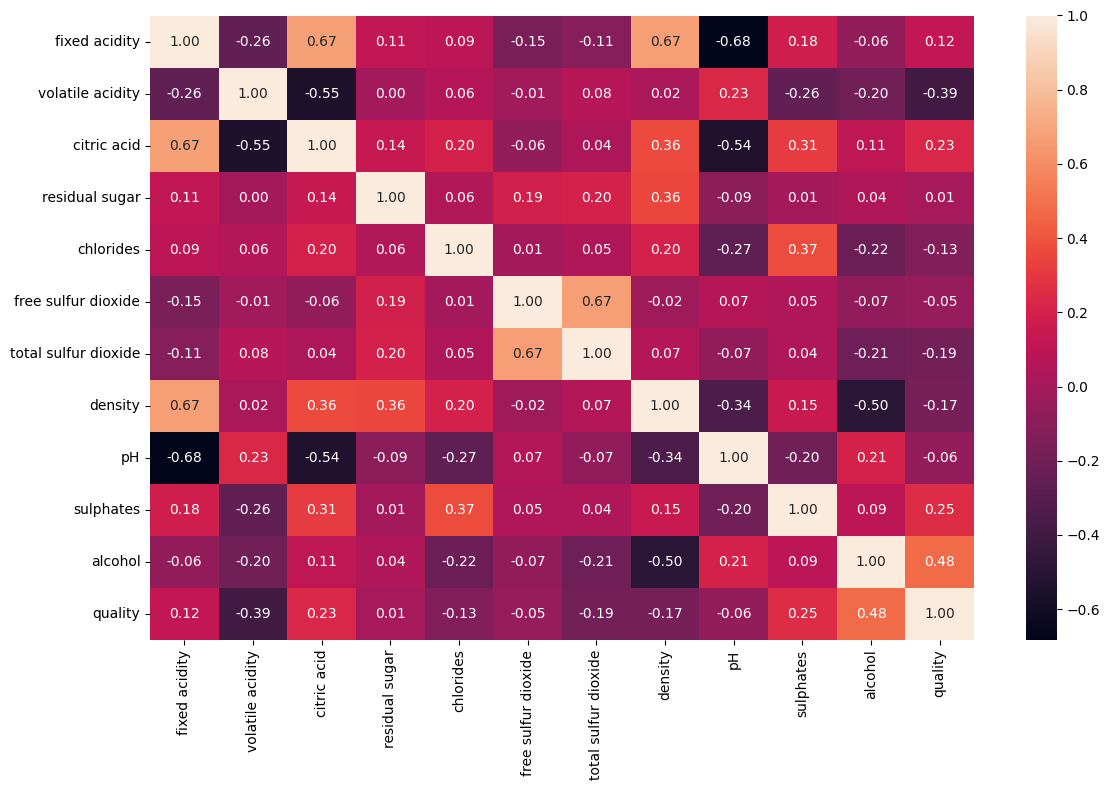

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 변수 간의 관계 파악
plt.figure(figsize=(12, 8))
sns.heatmap(red_wine_data.corr(), annot=True, fmt=".2f")
plt.tight_layout()

from google.colab import files
plt.savefig('sample_plot.png', bbox_inches='tight')
files.download('sample_plot.png')
plt.show()

density와 residual sugar가 설명변수간의 상관관계가 높다고 나옴

In [ ]:
import seaborn as sns

# Pairwise scatter plot 그리기
sns.set(style="ticks")
sns.pairplot(red_wine_data, diag_kind='kde', markers='o')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

quality값에서 5이하의 값만 그래프로 표현

In [ ]:
low_data_count = red_wine_data[red_wine_data['quality'] < 5]['quality'].count()

In [ ]:
print(low_data_count/red_wine_data['quality'].count() * 100 , '%')

모든 설명변수를 넣고 ols 실행

In [ ]:
import statsmodels.api as sm
X = red_wine_data.drop('quality', axis=1)
y = red_wine_data['quality']
X = sm.add_constant(X)
model = sm.OLS(y,X)
results = model.fit()
print(results.params)
print(results.summary())

const                   21.965208
fixed acidity            0.024991
volatile acidity        -1.083590
citric acid             -0.182564
residual sugar           0.016331
chlorides               -1.874225
free sulfur dioxide      0.004361
total sulfur dioxide    -0.003265
density                -17.881164
pH                      -0.413653
sulphates                0.916334
alcohol                  0.276198
dtype: float64
                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.361
Model:                            OLS   Adj. R-squared:                  0.356
Method:                 Least Squares   F-statistic:                     81.35
Date:                Sat, 11 Nov 2023   Prob (F-statistic):          1.79e-145
Time:                        03:52:36   Log-Likelihood:                -1569.1
No. Observations:                1599   AIC:                             3162.
Df Residuals:           

In [ ]:
model = sm.OLS(y,X).fit()
residuals = model.resid
residuals

0      -0.032850
1      -0.137880
2      -0.209895
3       0.306142
4      -0.032850
          ...   
1594   -0.529771
1595    0.038387
1596    0.056957
1597   -0.470756
1598   -0.008196
Length: 1599, dtype: float64

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

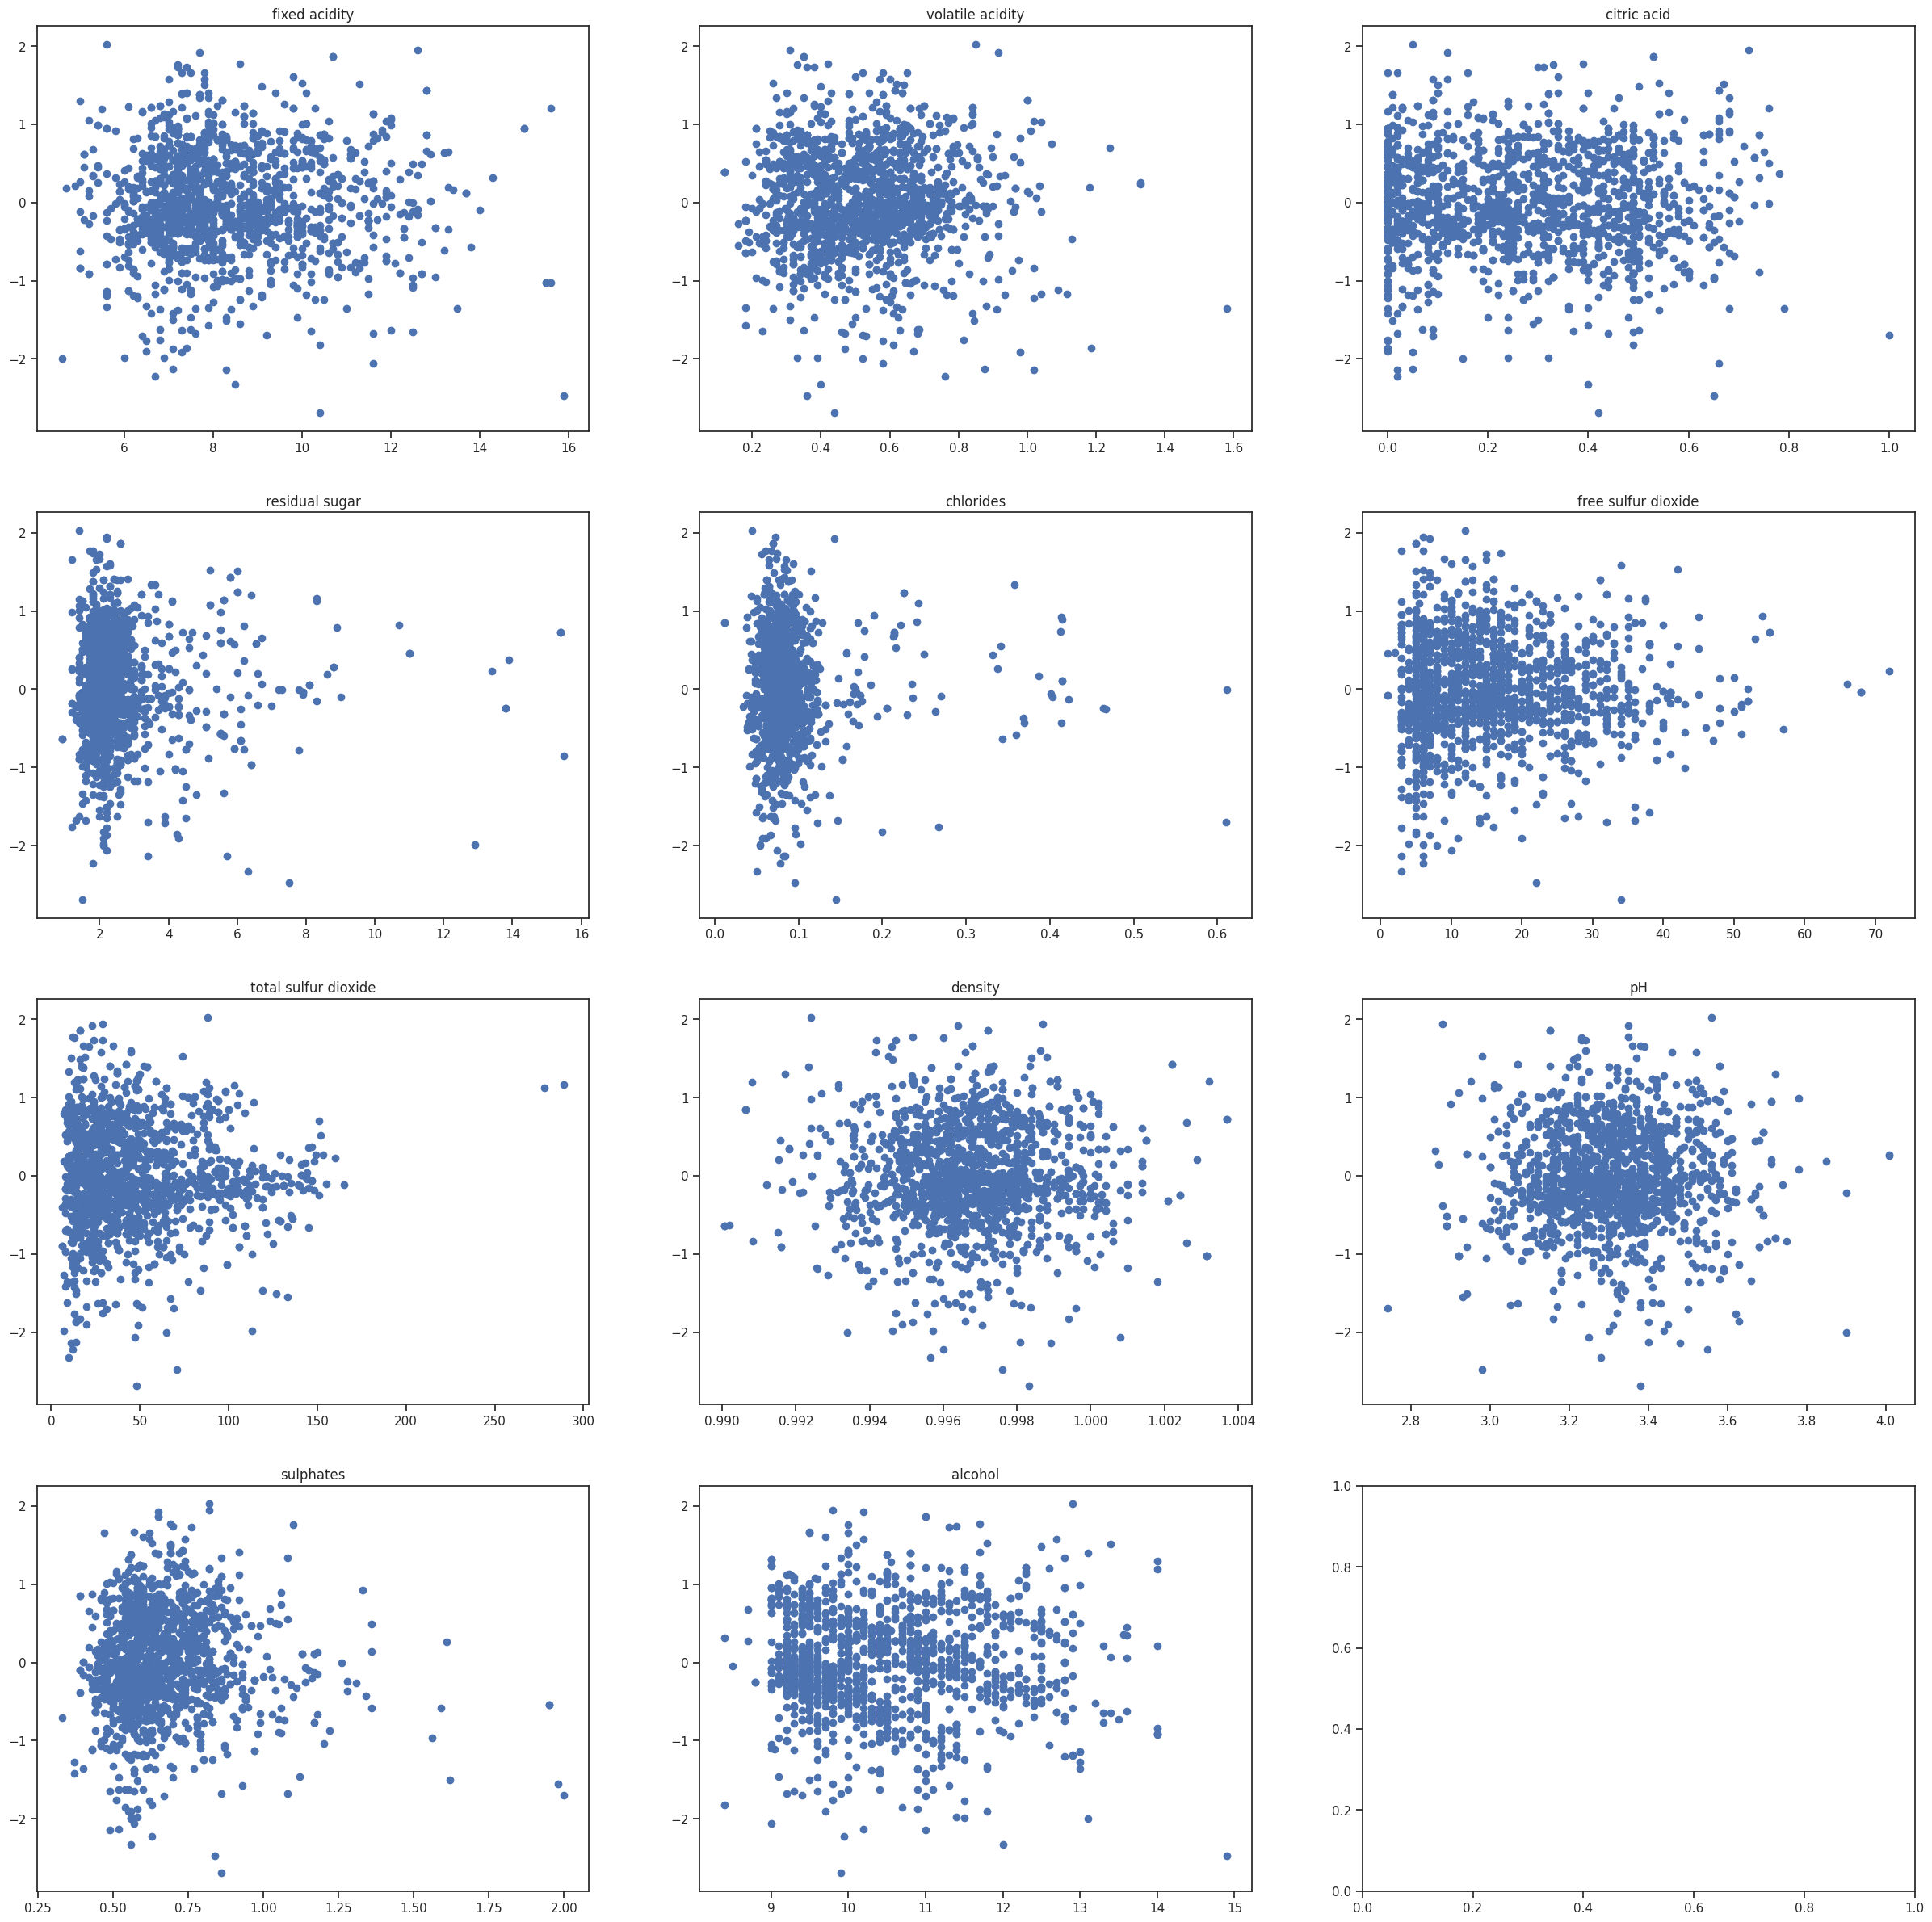

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(30, 30))
axes = axes.ravel()

for i, col in enumerate(X.columns[1:]):
  axes[i].scatter(X[col], residuals)
  axes[i].set_title(f'{col}')

plt.savefig('scatter_plots.png')
from google.colab import files
files.download('scatter_plots.png')
plt.show()

# 잔차 플롯

In [1]:
sm.graphics.tsa.plot_acf(residuals, lags=40)  # 자기상관도 플롯
sm.qqplot(residuals, line='s')  # QQ 플롯

plt.show()

NameError: ignored

quality가 3,4등급인 값들을 제거 후에 평균값을 넣어 ols

In [ ]:
high_quality_red_wine_data = red_wine_data[red_wine_data['quality'] > 5]
mean_quality = high_quality_red_wine_data['quality'].mean()
red_wine_data.loc[red_wine_data['quality'] < 5, 'quality'] = mean_quality

In [ ]:
import statsmodels.api as sm
X = red_wine_data.drop('quality', axis=1)
y = red_wine_data['quality']
X = sm.add_constant(X)
model = sm.OLS(y,X)
results = model.fit()
print(results.params)
print(results.summary())

red_wine_data에서 3,4등급 제거 전

In [ ]:
red_wine_data = pd.read_csv(url, sep=";")

total sulfur dioxide 제거 후 ols

In [ ]:
import statsmodels.api as sm
X = red_wine_data.drop('quality', axis=1)
X = X.drop('total sulfur dioxide', axis=1)
y = red_wine_data['quality']
X = sm.add_constant(X)
model = sm.OLS(y,X)
results = model.fit()
print(results.params)
print(results.summary())

total sulfur dioxide을 제거하는 것 고려해볼만 함 하지만 r2의 값이 너무 낮음

density 제거 후 ols

In [ ]:
import statsmodels.api as sm
X = red_wine_data.drop('quality', axis=1)
X = X.drop('density', axis=1)
y = red_wine_data['quality']
X = sm.add_constant(X)
model = sm.OLS(y,X)
results = model.fit()
print(results.params)
print(results.summary())

fixed acidity와 residual sugar의 데이터설명도의 신뢰성이 떨어짐

pH 제거 후 ols

In [ ]:
import statsmodels.api as sm
X = red_wine_data.drop('quality', axis=1)
X = X.drop('pH', axis=1)
y = red_wine_data['quality']
X = sm.add_constant(X)
model = sm.OLS(y,X)
results = model.fit()
print(results.params)
print(results.summary())

pH값을 제거하는 것은 회귀계수의 신뢰수준이 믿을 만 함

sulphates 값 제거 후 ols

In [ ]:
import statsmodels.api as sm
X = red_wine_data.drop('quality', axis=1)
X = X.drop('sulphates', axis=1)
y = red_wine_data['quality']
X = sm.add_constant(X)
model = sm.OLS(y,X)
results = model.fit()
print(results.params)
print(results.summary())

sulphates값은 다른 회귀계수에 영향을 줌

alcohol값 제거후 ols

In [ ]:
import statsmodels.api as sm
X = red_wine_data.drop('quality', axis=1)
X = X.drop('alcohol', axis=1)
y = red_wine_data['quality']
X = sm.add_constant(X)
model = sm.OLS(y,X)
results = model.fit()
print(results.params)
print(results.summary())

alcohol값 역시 삭제하지 않는 것이 맞음

측정값들 표준화할 필요가 있는가??? \
quality를 5,6으로 일정하게 3~4같은 저품질의 생산을 막는 것이 목표 \
density제거 후에도 r2의 값은 떨어지지 않음 \
회귀분석을 진행하는데에 여러통계적수치 ,회귀분석의 4가지 가정 고려할 점